# **Fashion-MNIST分类任务正则化对比实验**

## 注意事项

1、本案例使用AI框架：**MindSpore1.1.1**。

2、本案例最低硬件规格要求：**Ascend**。

3、切换硬件规格的方法：如需切换硬件规格，您可以在本页面右边的工作区进行切换。

4、运行代码方法：点击本页面顶部菜单栏的三角形运行按钮或按Ctrl + Enter键运行每个方块中的代码。

5、JupyterLab的详细用法：[请参考《ModelAtrs JupyterLab使用指导》](https://bbs.huaweicloud.com/forum/thread-97603-1-1.html)

6、Kernel Restarting、Kernel died及其他常见问题的解决办法： [请参考《ModelAtrs JupyterLab常见问题解决办法》](https://bbs.huaweicloud.com/forum/thread-98681-1-1.html)

## 案例内容介绍

本案例使用Fashion-MNIST数据集，它是一个替代MNIST手写数字集的图像数据集，由Zalando（一家德国的时尚科技公司）旗下的研究部门提供。其涵盖了来自10种类别的共7万个不同商品的正面图片。Fashion-MNIST的大小、格式和训练集/测试集划分与原始的MNIST完全一致。60000/10000的训练测试数据划分，28x28的灰度图片。通过上述实验我们对比不同正则化技术效果，此实验我们应用正则化技术做案例分析，并对比有无正则化的训练结果。

## 实验目标

- 掌握如何使用MindSpore进行卷积神经网络的开发。
- 了解如何使用MindSpore进行简单图片分类任务的训练。
- 了解如何使用MindSpore进行简单图片分类任务的测试和预测。
- 对比不同正则化技术效果。

## 实验步骤

### 1、数据集下载

本实验需要用到的是Fashion-MNIST数据集，由于华为云下载该数据集会花费较多时间，因此可以选择从OBS上下载并解压到notebook的环境中。

Fashion Mnist有10个标签，如下表所示：

| 标签 | 描述        |
| ---- | ----------- |
| 0    | T-shirt/top |
| 1    | Trouser     |
| 2    | Pullover    |
| 3    | Dress       |
| 4    | Coat        |
| 5    | Sandal      |
| 6    | Shirt       |
| 7    | Sneaker     |
| 8    | Bag         |
| 9    | Ankle boot  |


只下载一次就可

In [1]:
#从OBS桶下载数据集
!wget https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com/course/hwc_edu/python_module_framework/datasets/mindspore_data/fashion-mnist.zip
#解压文件
!unzip ./fashion-mnist.zip
!tree ./fashion-mnist/

--2021-05-27 02:36:03--  https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com/course/hwc_edu/python_module_framework/datasets/mindspore_data/fashion-mnist.zip
Resolving proxy-notebook.modelarts-dev-proxy.com (proxy-notebook.modelarts-dev-proxy.com)... 192.168.0.172
Connecting to proxy-notebook.modelarts-dev-proxy.com (proxy-notebook.modelarts-dev-proxy.com)|192.168.0.172|:8083... connected.
Proxy request sent, awaiting response... 200 OK
Length: 30879838 (29M) [application/zip]
Saving to: ‘fashion-mnist.zip’

fashion-mnist.zip   100%[===================>]  29.45M  77.0MB/s    in 0.4s    

2021-05-27 02:36:04 (77.0 MB/s) - ‘fashion-mnist.zip’ saved [30879838/30879838]

Archive:  ./fashion-mnist.zip
   creating: fashion-mnist/
   creating: fashion-mnist/test/
  inflating: fashion-mnist/test/t10k-images-idx3-ubyte  
  inflating: fashion-mnist/test/t10k-labels-idx1-ubyte  
   creating: fashion-mnist/train/
  inflating: fashion-mnist/train/train-images-idx3-ubyte  
  inflating: fashi

### 2、导入MindSpore模块和辅助模块

In [2]:
import os
import struct
import sys
from easydict import EasyDict as edict

import matplotlib.pyplot as plt
import numpy as np

import mindspore
import mindspore.dataset as ds
import mindspore.nn as nn
from mindspore import context
from mindspore.nn.metrics import Accuracy
from mindspore.train import Model
from mindspore.train.callback import ModelCheckpoint, CheckpointConfig, LossMonitor, TimeMonitor
from mindspore import Tensor

context.set_context(mode=context.GRAPH_MODE, device_target="Ascend")

### 3、变量定义

In [3]:
cfg = edict({
    'train_size': 60000,  # 训练集大小
    'test_size': 10000,  # 测试集大小
    'channel': 1,  # 图片通道数
    'image_height': 28,  # 图片高度
    'image_width': 28,  # 图片宽度
    'batch_size': 64,
    'num_classes': 10,  # 分类类别
    'lr': 0.001,  # 学习率
    'epoch_size': 20,  # 训练次数
    'data_dir_train': os.path.join('./fashion-mnist', 'train'),
    'data_dir_test': os.path.join('./fashion-mnist', 'test'),
})

### 4、读取并处理数据

读取数据

In [4]:
def read_image(file_name):
    '''
    :param file_name: 文件路径
    :return:  训练或者测试数据
    如下是训练的图片的二进制格式
    [offset] [type]          [value]          [description]
    0000     32 bit integer  0x00000803(2051) magic number
    0004     32 bit integer  60000            number of images
    0008     32 bit integer  28               number of rows
    0012     32 bit integer  28               number of columns
    0016     unsigned byte   ??               pixel
    0017     unsigned byte   ??               pixel
    ........
    xxxx     unsigned byte   ??               pixel
    '''
    file_handle = open(file_name, "rb")  # 以二进制打开文档
    file_content = file_handle.read()  # 读取到缓冲区中
    head = struct.unpack_from('>IIII', file_content, 0)  # 取前4个整数，返回一个元组
    offset = struct.calcsize('>IIII')
    imgNum = head[1]  # 图片数
    width = head[2]  # 宽度
    height = head[3]  # 高度
    bits = imgNum * width * height  # data一共有60000*28*28个像素值
    bitsString = '>' + str(bits) + 'B'  # fmt格式：'>47040000B'
    imgs = struct.unpack_from(bitsString, file_content, offset)  # 取data数据，返回一个元组
    imgs_array = np.array(imgs, np.float32).reshape((imgNum, width * height))  # 最后将读取的数据reshape成 【图片数，图片像素】二维数组
    return imgs_array


def read_label(file_name):
    '''
    :param file_name:
    :return:
    标签的格式如下：
    [offset] [type]          [value]          [description]
    0000     32 bit integer  0x00000801(2049) magic number (MSB first)
    0004     32 bit integer  60000            number of items
    0008     unsigned byte   ??               label
    0009     unsigned byte   ??               label
    ........
    xxxx     unsigned byte   ??               label
    The labels values are 0 to 9.
    '''
    file_handle = open(file_name, "rb")  # 以二进制打开文档
    file_content = file_handle.read()  # 读取到缓冲区中
    head = struct.unpack_from('>II', file_content, 0)  # 取前2个整数，返回一个元组
    offset = struct.calcsize('>II')
    labelNum = head[1]  # label数
    bitsString = '>' + str(labelNum) + 'B'  # fmt格式：'>47040000B'
    label = struct.unpack_from(bitsString, file_content, offset)  # 取data数据，返回一个元组
    return np.array(label, np.int32)


def get_data():
    # 文件获取
    train_image = os.path.join(cfg.data_dir_train, 'train-images-idx3-ubyte')
    test_image = os.path.join(cfg.data_dir_test, "t10k-images-idx3-ubyte")
    train_label = os.path.join(cfg.data_dir_train, "train-labels-idx1-ubyte")
    test_label = os.path.join(cfg.data_dir_test, "t10k-labels-idx1-ubyte")
    # 读取数据
    train_x = read_image(train_image)
    test_x = read_image(test_image)
    train_y = read_label(train_label)
    test_y = read_label(test_label)
    return train_x, train_y, test_x, test_y

数据预处理和处理结果图片展示

图像最后一个维度，即通道（颜色），使用reshape()函数将其添加到train_images和test_images的维度中。在这种情况下，它是单一颜色，因此通道为1，即“灰度”。为了减少计算量，还需要把图片的像素值进行归一化，八位图像的像素值范围在0-255之间，将所有像素值除以255，使得像素值范围控制在0-1之间。并打印数据集形状和一张图片作为例子。

训练数据集样本数： 60000
测试数据集样本数： 10000
通道数/图像长/宽： (1, 28, 28)
一张图像的标签样式： 9


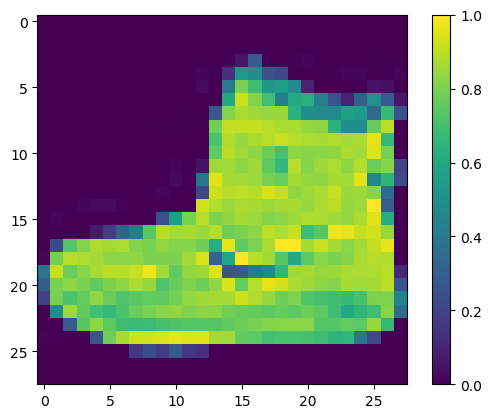

In [5]:
train_x, train_y, test_x, test_y = get_data()
train_x = train_x.reshape(-1, 1, cfg.image_height, cfg.image_width)
test_x = test_x.reshape(-1, 1, cfg.image_height, cfg.image_width)
train_x = train_x / 255.0
test_x = test_x / 255.0

print('训练数据集样本数：', train_x.shape[0])
print('测试数据集样本数：', test_y.shape[0])
print('通道数/图像长/宽：', train_x.shape[1:])
print('一张图像的标签样式：', train_y[0])  # 一共10类，用0-9的数字表达类别。

plt.figure()
plt.imshow(train_x[0,0,...])
plt.colorbar()
plt.grid(False)
plt.show()

### 5、转换数据类型为Dataset
在训练之前，需要先对数据集中的数据进行“洗牌”，打乱数据集的顺序。

In [6]:
def create_dataset():
    XY_train = list(zip(train_x, train_y))
    ds_train = ds.GeneratorDataset(XY_train, ['x', 'y'])
    ds_train = ds_train.shuffle(buffer_size=1000).batch(cfg.batch_size, drop_remainder=True)
    XY_test = list(zip(test_x, test_y))
    ds_test = ds.GeneratorDataset(XY_test, ['x', 'y'])
    ds_test = ds_test.shuffle(buffer_size=1000).batch(cfg.batch_size, drop_remainder=True)
    return ds_train, ds_test

### 6、定义卷积神经网络
该实验中，可以选择使用**不含正则化**的卷积神经网络或者选择**加入正则化**的卷积神经网络，用于对比结果。

下面这部分用于创建不加入正则化的卷积神经网络，网络结构为：卷积层1 -> 卷积层2 -> 卷积层3 -> 最大池化层 -> 全连接层1 -> 全连接层2。

In [7]:
# 定义卷积神经网络，无正则化
class ForwardFashion(nn.Cell):
    def __init__(self, num_class=10):  # 一共分十类，图片通道数是1
        super(ForwardFashion, self).__init__()
        self.num_class = num_class
        self.conv1 = nn.Conv2d(1, 32,kernel_size=3, stride=1, padding=0, has_bias=False, pad_mode="valid")
        self.conv2 = nn.Conv2d(32, 64,kernel_size=3, stride=1, padding=0, has_bias=False, pad_mode="valid")
        self.conv3 = nn.Conv2d(64, 128,kernel_size=3, stride=1, padding=0, has_bias=False, pad_mode="valid")
        self.maxpool2d = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Dense(128 * 11 * 11, 128)
        self.fc2 = nn.Dense(128, self.num_class)

    def construct(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.maxpool2d(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

下面这部分用于创建加入正则化的卷积神经网络

网络结构为卷积层1 -> dropout层1 -> 卷积层2 -> dropout层1 -> 卷积层3 -> dropout层1 -> 最大池化层 ->  dropout层2 -> 全连接层1 -> dropout层2 -> 全连接层2：

In [8]:
# 定义卷积神经网络，有正则化
class ForwardFashionRegularization(nn.Cell):
    def __init__(self, num_class=10):  # 一共分十类，图片通道数是1
        super(ForwardFashionRegularization, self).__init__()
        self.num_class = num_class
        self.conv1 = nn.Conv2d(1, 32,kernel_size=3, stride=1, padding=0, has_bias=False, pad_mode="valid")
        self.conv2 = nn.Conv2d(32, 64,kernel_size=3, stride=1, padding=0, has_bias=False, pad_mode="valid")
        self.conv3 = nn.Conv2d(64, 128,kernel_size=3, stride=1, padding=0, has_bias=False, pad_mode="valid")
        self.maxpool2d = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Dense(3200, 128)
        self.bn = nn.BatchNorm1d(128)
        self.fc2 = nn.Dense(128, self.num_class)

    def construct(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.maxpool2d(x)
        x = self.dropout(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.maxpool2d(x)
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.bn(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

### 7、训练
为这个模型指定优化器（adam）、损失函数（crossentropy）和度量(accuracy)，然后启动训练，最后进行验证。

使用Fashion-MNIST数据集对上述定义的卷积神经网络模型进行训练。训练策略如下表所示，可以调整训练策略并查看训练效果。

| batch size | number of epochs | learning rate | input shape | optimizer |
| ---------- | ---------------- | ------------- | ----------- | --------- |
| 64         | 20               | 0.001         | (1，28，28) | Adam      |

In [9]:
# 定义训练函数
def train(Net):
    ds_train, ds_test = create_dataset()
    # 构建网络
    network = Net(cfg.num_classes)
    # 定义模型的损失函数，优化器
    net_loss = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction="mean")
    net_opt = nn.Adam(network.trainable_params(), cfg.lr)
    # 训练模型
    model = Model(network, loss_fn=net_loss, optimizer=net_opt, metrics={'acc': Accuracy()})
    loss_cb = LossMonitor()
    print("============== Starting Training ==============")
    model.train(20, ds_train, callbacks=[loss_cb], dataset_sink_mode=True) 
    # 验证
    metric = model.eval(ds_test)
    print(metric)
    
    return model

In [10]:
# 训练并验证无正则化的网络
model = train(ForwardFashion)

============== Starting Training ==============
epoch: 1 step: 937, loss is 0.42774364
epoch: 2 step: 937, loss is 0.18854634
epoch: 3 step: 937, loss is 0.1570454
epoch: 4 step: 937, loss is 0.13949916
epoch: 5 step: 937, loss is 0.26174447
epoch: 6 step: 937, loss is 0.22709055
epoch: 7 step: 937, loss is 0.18964554
epoch: 8 step: 937, loss is 0.08324427
epoch: 9 step: 937, loss is 0.06425335
epoch: 10 step: 937, loss is 0.11771837
epoch: 11 step: 937, loss is 0.060660865
epoch: 12 step: 937, loss is 0.07811035
epoch: 13 step: 937, loss is 0.051035
epoch: 14 step: 937, loss is 0.01041508
epoch: 15 step: 937, loss is 0.016669953
epoch: 16 step: 937, loss is 0.040017504
epoch: 17 step: 937, loss is 0.020863958
epoch: 18 step: 937, loss is 0.0099992845
epoch: 19 step: 937, loss is 0.091565736
epoch: 20 step: 937, loss is 0.06977551
{'acc': 0.9122596153846154}


In [11]:
# 训练并验证有正则化的网络。
model = train(ForwardFashionRegularization)

============== Starting Training ==============
epoch: 1 step: 937, loss is 0.38134933
epoch: 2 step: 937, loss is 0.2929163
epoch: 3 step: 937, loss is 0.39226422
epoch: 4 step: 937, loss is 0.26957458
epoch: 5 step: 937, loss is 0.2422479
epoch: 6 step: 937, loss is 0.22728926
epoch: 7 step: 937, loss is 0.1890377
epoch: 8 step: 937, loss is 0.15112567
epoch: 9 step: 937, loss is 0.14651367
epoch: 10 step: 937, loss is 0.35065463
epoch: 11 step: 937, loss is 0.327967
epoch: 12 step: 937, loss is 0.2963117
epoch: 13 step: 937, loss is 0.22670943
epoch: 14 step: 937, loss is 0.104591995
epoch: 15 step: 937, loss is 0.32963303
epoch: 16 step: 937, loss is 0.3844468
epoch: 17 step: 937, loss is 0.2751771
epoch: 18 step: 937, loss is 0.31989223
epoch: 19 step: 937, loss is 0.29271936
epoch: 20 step: 937, loss is 0.1594594
{'acc': 0.9225761217948718}


### 8、预测
使用上述训练好的模型对测试数据集进行预测。打印预测结果

In [12]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#从测试集中取出一组样本，输入模型进行预测
ds_test, _ = create_dataset()
test_ = next(ds_test.create_dict_iterator(output_numpy=True))
#利用key值选出样
predictions = model.predict(Tensor(test_['x']))
predictions = predictions.asnumpy()
for i in range(15):
    p_np = predictions[i, :]
    pre_label = np.argmax(p_np)
    print('第' + str(i) + '个sample预测结果：', class_names[pre_label], '   真实结果：', class_names[test_['y'][i]])

第0个sample预测结果： Shirt    真实结果： Pullover
第1个sample预测结果： Bag    真实结果： Bag
第2个sample预测结果： Trouser    真实结果： Trouser
第3个sample预测结果： Pullover    真实结果： Pullover
第4个sample预测结果： Shirt    真实结果： Shirt
第5个sample预测结果： Sneaker    真实结果： Sneaker
第6个sample预测结果： Sneaker    真实结果： Sneaker
第7个sample预测结果： Dress    真实结果： Dress
第8个sample预测结果： Bag    真实结果： Bag
第9个sample预测结果： Bag    真实结果： Bag
第10个sample预测结果： Sneaker    真实结果： Sneaker
第11个sample预测结果： T-shirt/top    真实结果： T-shirt/top
第12个sample预测结果： Trouser    真实结果： Trouser
第13个sample预测结果： T-shirt/top    真实结果： T-shirt/top
第14个sample预测结果： Pullover    真实结果： Pullover


### 9、对预测结果可视化

In [13]:
# -------------------定义可视化函数--------------------------------
# 输入预测结果序列，真实标签序列，以及图片序列
# 目标是根据预测值对错，让其标签显示为红色或者蓝色。
def plot_image(predictions_array, true_label, img):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    # 显示对应图片
    plt.imshow(img, cmap=plt.cm.binary)
    # 显示预测结果的颜色，如果对上了是蓝色，否则为红色
    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    # 显示对应标签的格式，样式
    plt.xlabel('{},{:2.0f}% ({})'.format(class_names[predicted_label],
                                         100 * np.max(predictions_array),
                                         class_names[true_label]), color=color)


In [14]:
# 将预测的结果以柱状图形状显示蓝对红错
def plot_value_array(predictions_array, true_label):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    this_plot = plt.bar(range(10), predictions_array, color='#777777')
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    this_plot[predicted_label].set_color('red')
    this_plot[true_label].set_color('blue')

In [15]:
import numpy as np
def softmax_np(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    softmax_x = exp_x/np.sum(exp_x)
    return softmax_x

预测结果可视化，输入预测结果序列，真实标签序列，以及图片序列。目标是根据预测值对错，让其标签显示为红色或者蓝色。对：标签为蓝色；错：标签为红色。最后预测15个图像与标签，将预测的结果以柱状图形状显示蓝对红错。

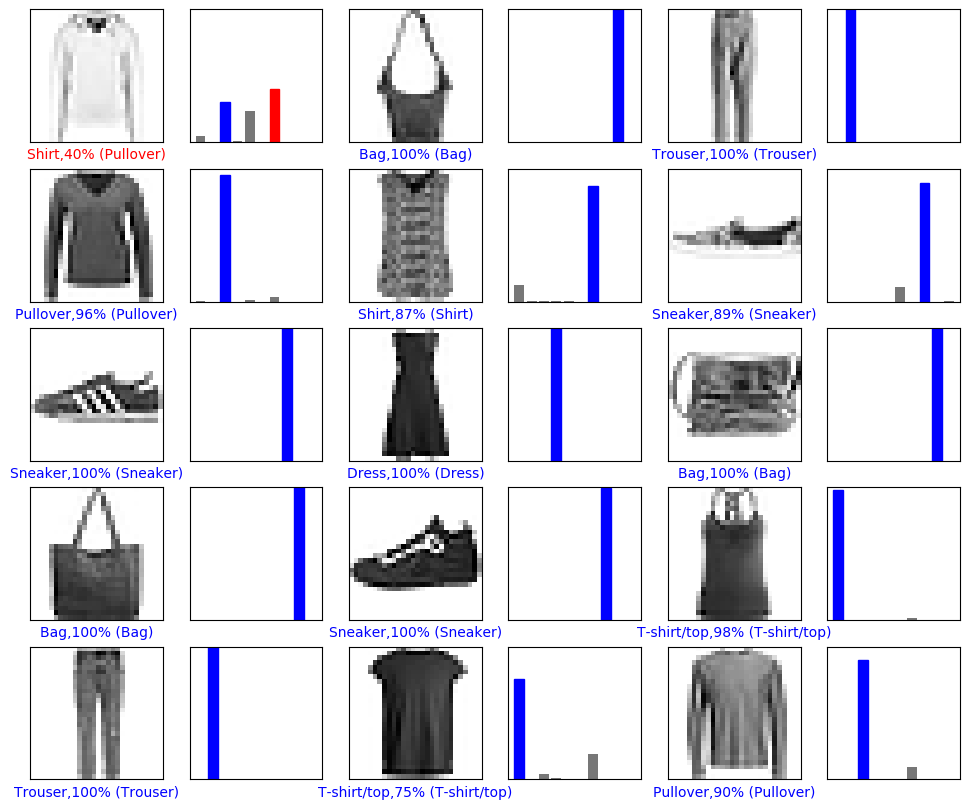

In [16]:
# 预测15个图像与标签，并展现出来
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    pred_np_ = predictions[i, :]
    pred_np_ = softmax_np(pred_np_)
    plot_image(pred_np_, test_['y'][i], test_['x'][i, 0, ...])
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(pred_np_, test_['y'][i])
plt.show()

## 实验总结
本章提供了一个FashionMnist正则化前后对比实验。该实验选取FashionMnist灰度数据集将模型进行训练预测，当初始模型表现过拟合时，参数量多的模型的性能反而不如参数量少的模型，我们加入正则化技术重新建立新模型并预测。

## 创新设计
基于本实验描述，尝试其他数据集进行正则化前后对比实验。

至此，本案例完成。